# AgriPrice-IQ: Probabilistic Future Forecasting (Aug 2026 – Jul 2027)
In this notebook, we train LightGBM Quantile Regressors on the complete historical dataset (Jan 2021 – July 2026). We then perform iterative multi-step forecasting to project retail food prices, along with their P10/P50/P90 uncertainty bounds, for the next 12 months (August 2026 to July 2027).

In [3]:
import sqlite3
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to database and load all engineered features
conn = sqlite3.connect('../database/agriprice_iq.db')
df = pd.read_sql("SELECT * FROM model_features;", conn)
conn.close()

df['date'] = pd.to_datetime(df['date'])
print(f"Loaded full feature dataset shape: {df.shape}")

# Define feature columns (dropping targets, dates, and non-numeric identifiers)
drop_cols = ['date', 'province', 'product_name', 'category', 'price', 'unit', 'uom', 'scalar_factor', 'scalar_id', 'date_raw']
feature_cols = [
    col for col in df.columns 
    if col not in drop_cols and pd.api.types.is_numeric_dtype(df[col])
]

X_all = df[feature_cols]
y_all = df['price']

print(f"Training on all historical samples: {X_all.shape[0]} rows using {len(feature_cols)} numerical features.")

Loaded full feature dataset shape: (61181, 19)
Training on all historical samples: 61181 rows using 13 numerical features.


In [4]:
quantiles = [0.10, 0.50, 0.90]
models = {}

for q in quantiles:
    print(f"Training LightGBM model for Quantile: {q}...")
    model = lgb.LGBMRegressor(
        objective='quantile',
        alpha=q,
        n_estimators=150,
        learning_rate=0.05,
        random_state=42,
        verbose=-1
    )
    model.fit(X_all, y_all)
    models[q] = model

print("All future forecasting quantile models trained successfully!")

Training LightGBM model for Quantile: 0.1...
Training LightGBM model for Quantile: 0.5...
Training LightGBM model for Quantile: 0.9...
All future forecasting quantile models trained successfully!


In [6]:
# We will forecast month-by-month iteratively for each province-product combination
future_dates = pd.date_range(start='2026-08-01', end='2027-07-01', freq='MS')

# Get latest available historical row for each group to initialize recursive lags
latest_history = df.sort_values('date').groupby(['province', 'product_name']).last().reset_index()

future_predictions = []

for _, row in latest_history.iterrows():
    province = row['province']
    product_name = row['product_name']
    category = row['category'] if 'category' in df.columns else 'General'
    unit = row['unit'] if 'unit' in df.columns else 'CAD'
    
    # Maintain a working history tracker for this specific group
    group_history = df[(df['province'] == province) & (df['product_name'] == product_name)].sort_values('date').copy()
    
    for target_date in future_dates:
        # Construct feature vector for the target future date
        feat_dict = {}
        feat_dict['year'] = target_date.year
        feat_dict['month'] = target_date.month
        feat_dict['quarter'] = target_date.quarter
        feat_dict['month_sin'] = np.sin(2 * np.pi * target_date.month / 12)
        feat_dict['month_cos'] = np.cos(2 * np.pi * target_date.month / 12)
        
        # Extract lags from recent history
        vals = group_history['price'].values
        feat_dict['lag_1'] = vals[-1] if len(vals) >= 1 else row['price']
        feat_dict['lag_3'] = vals[-3] if len(vals) >= 3 else feat_dict['lag_1']
        feat_dict['lag_6'] = vals[-6] if len(vals) >= 6 else feat_dict['lag_3']
        feat_dict['lag_12'] = vals[-12] if len(vals) >= 12 else feat_dict['lag_6']
        
        # Rolling stats based on recent values
        recent_vals_3 = vals[-3:] if len(vals) >= 3 else vals
        recent_vals_6 = vals[-6:] if len(vals) >= 6 else vals
        feat_dict['rolling_mean_3m'] = np.mean(recent_vals_3)
        feat_dict['rolling_std_3m'] = np.std(recent_vals_3) if len(recent_vals_3) > 1 else 0.0
        feat_dict['rolling_mean_6m'] = np.mean(recent_vals_6)
        feat_dict['rolling_std_6m'] = np.std(recent_vals_6) if len(recent_vals_6) > 1 else 0.0
        
        # Build dataframe input for model
        X_future = pd.DataFrame([feat_dict])[feature_cols]
        
        # Predict P10, P50, P90
        p10 = models[0.10].predict(X_future)[0]
        p50 = models[0.50].predict(X_future)[0]
        p90 = models[0.90].predict(X_future)[0]
        
        # Store prediction record
        future_predictions.append({
            'date': target_date,
            'province': province,
            'product_name': product_name,
            'category': category,
            'unit': unit,
            'pred_p10': p10,
            'pred_p50': p50,
            'pred_p90': p90,
            'confidence_spread': p90 - p10
        })
        
        # Append predicted P50 to working history so subsequent months can use it as a lag
        new_row = pd.DataFrame({'date': [target_date], 'price': [p50]})
        group_history = pd.concat([group_history, new_row], ignore_index=True)

df_future_preds = pd.DataFrame(future_predictions)
print(f"Generated {len(df_future_preds)} future forecast records (Aug 2026 – Jul 2027)!")
display(df_future_preds.head(10))

Generated 13188 future forecast records (Aug 2026 – Jul 2027)!


,date,province,product_name,category,unit,pred_p10,pred_p50,pred_p90,confidence_spread
0,2026-08-01,Alberta,"Almonds, 200 grams 6",Pantry Staples,CAD,5.334148,5.526083,5.650705,0.316557
1,2026-09-01,Alberta,"Almonds, 200 grams 6",Pantry Staples,CAD,5.209936,5.484722,5.630932,0.420995
2,2026-10-01,Alberta,"Almonds, 200 grams 6",Pantry Staples,CAD,5.195745,5.462506,5.583964,0.388218
3,2026-11-01,Alberta,"Almonds, 200 grams 6",Pantry Staples,CAD,5.330576,5.460677,5.623812,0.293236
4,2026-12-01,Alberta,"Almonds, 200 grams 6",Pantry Staples,CAD,5.358836,5.489604,5.678827,0.319991
5,2027-01-01,Alberta,"Almonds, 200 grams 6",Pantry Staples,CAD,5.449292,5.524117,5.677809,0.228517
6,2027-02-01,Alberta,"Almonds, 200 grams 6",Pantry Staples,CAD,5.439568,5.541111,5.686559,0.246991
7,2027-03-01,Alberta,"Almonds, 200 grams 6",Pantry Staples,CAD,5.427288,5.521853,5.686968,0.259681
8,2027-04-01,Alberta,"Almonds, 200 grams 6",Pantry Staples,CAD,5.450195,5.560811,5.680306,0.230111
9,2027-05-01,Alberta,"Almonds, 200 grams 6",Pantry Staples,CAD,5.446568,5.541793,5.677324,0.230756


In [34]:
# 1. Print available products so you can see the exact names
print("Available products to choose from:")
print(df_future_preds['product_name'].unique()[30:]) # prints based on whatever you want

Available products to choose from:
['Chicken breasts, per kilogram 5' 'Chicken drumsticks, per kilogram 5'
 'Chicken thigh, per kilogram 5'
 'Cookies and sweet biscuits, 300 grams  6'
 'Crackers and crisp breads, 200 grams  5' 'Cream, 1 litre 5'
 'Cucumber, unit 5' 'Deodorant, 85 grams 6' 'Dried lentils, 900 grams 6'
 'Dry beans and legumes, 900 grams  6' 'Dry or fresh pasta, 500 grams 6'
 'Eggs, 1 dozen 5' 'Flatbread and pita, 500 grams  6'
 'Frozen broccoli, 500 grams 5' 'Frozen corn, 750 grams  6'
 'Frozen french fried potatoes, 750 grams 6'
 'Frozen green beans, 750 grams 6' 'Frozen mixed vegetables, 750 grams  6'
 'Frozen peas, 750 grams 6' 'Frozen pizza, 390 grams 6'
 'Frozen spinach, 300 grams 6' 'Frozen strawberries, 600 grams 5'
 'Grapes, per kilogram 5' 'Ground beef, per kilogram 5'
 'Hummus, 227 grams 6' 'Iceberg lettuce, unit 5'
 'Infant formula, 900 grams  6' 'Ketchup, 1 litre 6'
 'Laundry detergent, 4.43 litres 6' 'Lemons, unit 5' 'Limes, unit 5'
 'Margarine, 907 grams 6'

Historical records found: 55 | Future predictions found: 12


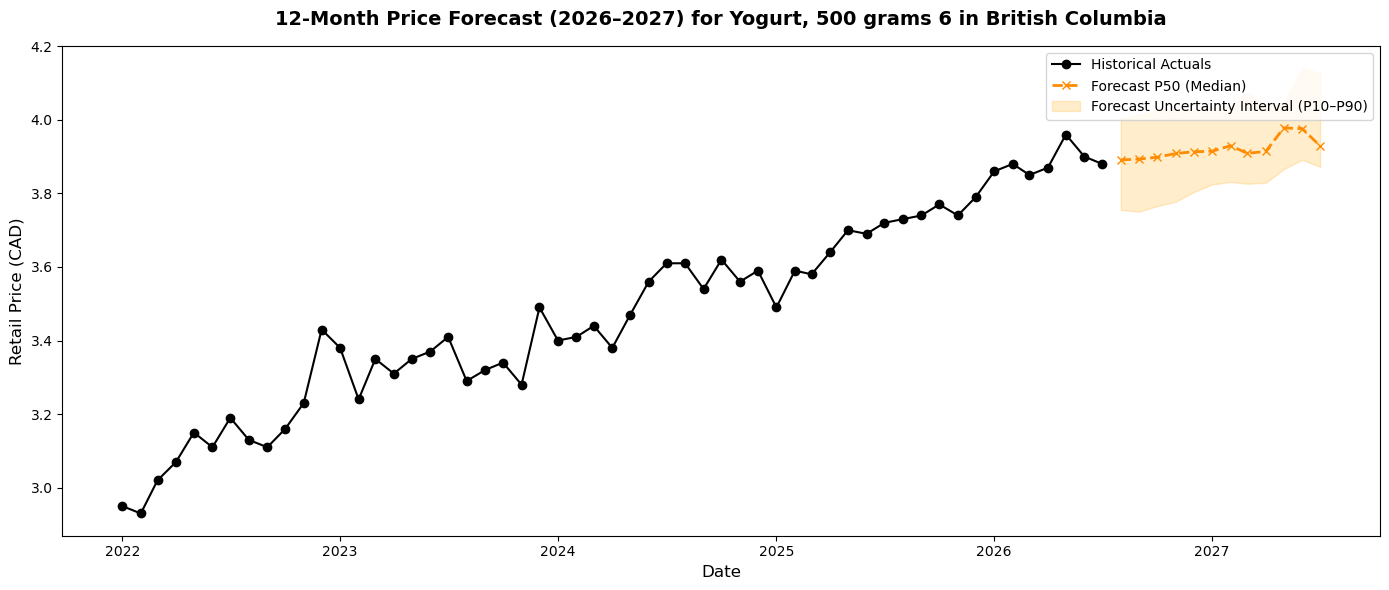

In [35]:
# 2. Set your custom province and exact product name here:
sample_province = 'British Columbia'
sample_product = 'Yogurt, 500 grams 6' # Replace with an exact name from the list above

# Filter datasets safely
hist_sub = df[(df['province'] == sample_province) & (df['product_name'] == sample_product)]
fut_sub = df_future_preds[(df_future_preds['province'] == sample_province) & (df_future_preds['product_name'] == sample_product)].sort_values('date')

# Check if data exists before plotting
print(f"Historical records found: {len(hist_sub)} | Future predictions found: {len(fut_sub)}")

if len(fut_sub) > 0:
    plt.figure(figsize=(14, 6))
    plt.plot(hist_sub['date'], hist_sub['price'], label='Historical Actuals', color='black', marker='o', linewidth=1.5)
    plt.plot(fut_sub['date'], fut_sub['pred_p50'], label='Forecast P50 (Median)', color='darkorange', linestyle='--', marker='x', linewidth=2)
    plt.fill_between(
        fut_sub['date'], 
        fut_sub['pred_p10'], 
        fut_sub['pred_p90'], 
        color='orange', 
        alpha=0.2, 
        label='Forecast Uncertainty Interval (P10–P90)'
    )

    plt.title(f'12-Month Price Forecast (2026–2027) for {sample_product} in {sample_province}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Retail Price (CAD)', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"⚠️ Warning: No data found for '{sample_product}'. Check the exact spelling from the list above!")

In [37]:
# Save future predictions table into SQLite and CSV file for direct connection to Tableau
conn = sqlite3.connect('../database/agriprice_iq.db')
df_future_preds.to_sql('future_predictions', conn, if_exists='replace', index=False)
df_future_preds.to_csv('../data/future_predictions.csv', index=False)
conn.close()

print("Future predictions successfully saved to SQLite table 'future_predictions'!")

Future predictions successfully saved to SQLite table 'future_predictions'!


In [38]:
# ==============================
# 1. Historical data
# ==============================

historical = df[
    ['date', 'province', 'product_name', 'category', 'price']
].copy()

historical = historical.rename(columns={
    'price': 'actual_price'
})

# Historical observations don't have forecasts
historical['pred_p10'] = np.nan
historical['pred_p50'] = np.nan
historical['pred_p90'] = np.nan


# ==============================
# 2. Forecast data
# ==============================

forecast = df_future_preds[
    ['date', 'province', 'product_name', 'category',
     'pred_p10', 'pred_p50', 'pred_p90']
].copy()

# Forecast observations don't have actual prices
forecast['actual_price'] = np.nan


# ==============================
# 3. Put columns in same order
# ==============================

columns = [
    'date',
    'province',
    'product_name',
    'category',
    'actual_price',
    'pred_p10',
    'pred_p50',
    'pred_p90'
]

historical = historical[columns]
forecast = forecast[columns]


# ==============================
# 4. Combine vertically
# ==============================

tableau_df = pd.concat(
    [historical, forecast],
    ignore_index=True
)


# ==============================
# 5. Clean date
# ==============================

tableau_df['date'] = pd.to_datetime(
    tableau_df['date'],
    errors='coerce'
)


# ==============================
# 6. Remove completely invalid rows
# ==============================

tableau_df = tableau_df.dropna(
    subset=['date', 'province', 'product_name']
)


# ==============================
# 7. Sort
# ==============================

tableau_df = tableau_df.sort_values(
    ['province', 'product_name', 'date']
).reset_index(drop=True)


# ==============================
# 8. Check the result
# ==============================

print(tableau_df.head(10))

print("\nShape:")
print(tableau_df.shape)

print("\nColumns:")
print(tableau_df.columns.tolist())

print("\nHistorical rows:")
print(tableau_df['actual_price'].notna().sum())

print("\nForecast rows:")
print(tableau_df['pred_p50'].notna().sum())


# ==============================
# 9. Export for Tableau
# ==============================

tableau_df.to_csv(
    '../data/tableau_price_forecast.csv',
    index=False
)

print("\nSaved as: tableau_price_forecast.csv")

        date province          product_name        category  actual_price  \
0 2022-01-01  Alberta  Almonds, 200 grams 6  Pantry Staples          5.29   
1 2022-02-01  Alberta  Almonds, 200 grams 6  Pantry Staples          5.32   
2 2022-03-01  Alberta  Almonds, 200 grams 6  Pantry Staples          5.25   
3 2022-04-01  Alberta  Almonds, 200 grams 6  Pantry Staples          5.13   
4 2022-05-01  Alberta  Almonds, 200 grams 6  Pantry Staples          5.35   
5 2022-06-01  Alberta  Almonds, 200 grams 6  Pantry Staples          5.29   
6 2022-07-01  Alberta  Almonds, 200 grams 6  Pantry Staples          5.29   
7 2022-08-01  Alberta  Almonds, 200 grams 6  Pantry Staples          5.24   
8 2022-09-01  Alberta  Almonds, 200 grams 6  Pantry Staples          5.31   
9 2022-10-01  Alberta  Almonds, 200 grams 6  Pantry Staples          5.04   

   pred_p10  pred_p50  pred_p90  
0       NaN       NaN       NaN  
1       NaN       NaN       NaN  
2       NaN       NaN       NaN  
3       NaN     

## Summary
We successfully executed an iterative 12-month future forecasting pipeline from August 2026 through July 2027 using the exact column schema (`date`, `province`, `product_name`, `price`). The resulting probabilistic projections are stored in the `future_predictions` SQLite and csv table, ready for visualization in Tableau.